In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [130]:
x = np.arange(1, 101)
np.random.seed(42)
epsilon = np.random.normal(0, 1, 100)
y = 3 + 5 * x + epsilon
data = pd.DataFrame({
    "X": x,
    "Y": y
})
data.to_csv("lab01_data.csv", index = False)

In [131]:
def load_data():
  data = pd.read_csv("lab01_data.csv")
  #data = pd.read_csv("data_01.csv", header = None)
  return data

In [132]:
def process_data(data):
  x = data["X"]
  y = data["Y"]
  x0 = np.ones(len(x))
  x_mean = np.mean(x)
  x_std = np.std(x)
  x_scaled = (x - x_mean)/x_std
  X = np.array([x0, x_scaled]).T
  return x, y, X

In [133]:
def compute_cost(X, y, theta):
  m = len(y)
  y_pred = X.dot(theta)
  error = y_pred - y
  cost = (1 / (2*m))*np.sum(error**2)
  return cost

In [134]:
def gradient_descent(X, y, theta, alpha, iters):
  m = len(y)
  cost_history = np.zeros(iters)
  for i in range(iters):
    y_pred = X.dot(theta)
    error = y_pred - y
    grad = (1 / m)*(X.T @ error)
    theta = theta - alpha * grad
    cost_history[i] = compute_cost(X, y, theta)
  return theta, cost_history

In [135]:
def train(X, y):
  theta = np.array([0.0, 0.0])
  learning_rate = 0.01
  iters = 1000
  theta, cost_history = gradient_descent(
      X,
      y,
      theta,
      learning_rate,
      iters
  )
  return theta, cost_history

In [136]:
def evaluate(X, y, theta):
  cost = compute_cost(X, y, theta)

  print("Learned parameters are:")
  print(theta)

  print("Final cost is:")
  print(cost)

  return cost

In [137]:
data = load_data()
x, y, X = process_data(data)
theta, cost_history = train(X, y)
cost = evaluate(X, y, theta)

Learned parameters are:
[255.38512771 144.3643355 ]
Final cost is:
0.4075325635667899


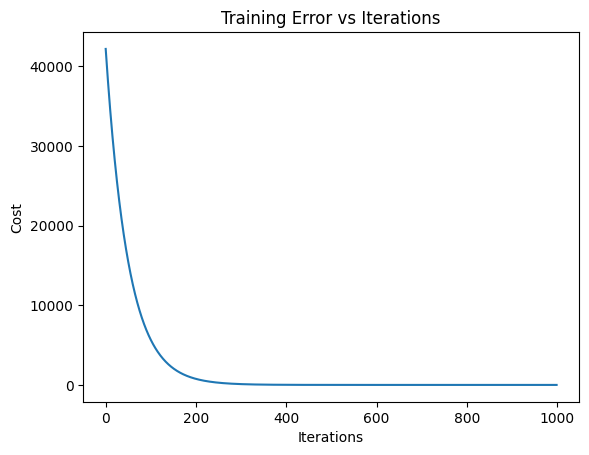

In [138]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Error vs Iterations")
plt.show()

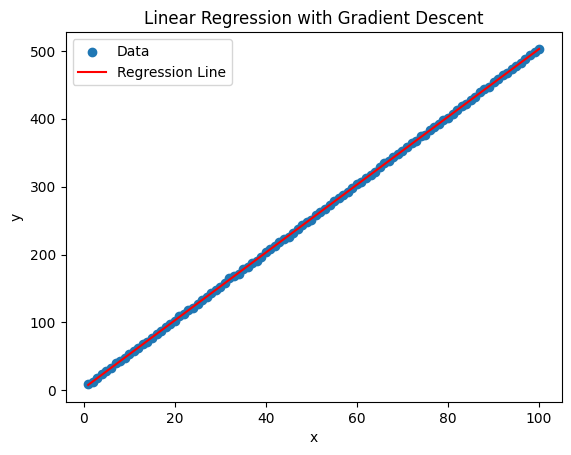

In [139]:
y_pred = X.dot(theta)

# Plot original data
plt.scatter(x, y, label="Data")

# Plot learned regression line
plt.plot(x, y_pred, color="red", label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression with Gradient Descent")
plt.legend()
plt.show()